# Is there nothing to find, or did we break something?

## Scope

`3_03` and `4_04` both fail to separate the annotated controls, at every level of
the model and under every weighting. A negative result of that kind has three
possible causes and they call for completely different responses:

| Cause | What it would mean | How to tell |
| --- | --- | --- |
| **no power** | ten peptides cannot detect an effect of any plausible size | simulate the test at known effect sizes |
| **broken pipeline** | the machinery cannot recover a signal even when one is present | plant a signal and check it comes back |
| **no signal** | the labels are not separable by this model, or by anything | try many predictors, not one |

This notebook runs all three checks. None of them uses the model's verdict; they
test the **test**, so that the negative in `3_03` can be attributed rather than
merely reported.

## Inputs and outputs

Inputs: `data/peptides_data/peptides_mic/controls_mic.csv`,
`results/3_03_control_discrimination.csv`.

Outputs: `results/3_04_power.csv`, `results/3_04_positive_control.csv`,
`results/3_04_alternative_predictors.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

import _analysis_common as common

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
SIGNIFICANCE = 0.05
# Effect sizes to simulate, as a shift between the two groups in units of the
# within-group standard deviation. Cohen's conventions put 0.8 at "large".
EFFECT_SIZES = (0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0)
N_POWER_DRAWS = 4000
# Group sizes to simulate: the one we have, and what would be needed.
GROUP_SIZES = ((4, 6), (8, 12), (15, 15), (25, 25), (50, 50))
SEED = common.SEED

# Kyte-Doolittle hydropathy, the standard scale for a GRAVY score.
HYDROPATHY = {
    "A": 1.8, "R": -4.5, "N": -3.5, "D": -3.5, "C": 2.5, "Q": -3.5, "E": -3.5,
    "G": -0.4, "H": -3.2, "I": 4.5, "L": 3.8, "K": -3.9, "M": 1.9, "F": 2.8,
    "P": -1.6, "S": -0.8, "T": -0.7, "W": -0.9, "Y": -1.3, "V": 4.2,
}
POSITIVE = set("KR")
NEGATIVE = set("DE")
AROMATIC = set("FWY")

rng = np.random.default_rng(SEED)
controls = pd.read_csv(common.CONTROLS_MIC_CSV)
discrimination = pd.read_csv(common.RESULTS_ROOT / "3_03_control_discrimination.csv")
print(f"controls: {len(controls)} ({controls['serum_fate'].value_counts().to_dict()})")

controls: 10 ({'labile': 6, 'stable': 4})


## Check 1: what could ten peptides have detected?

Before asking whether an effect is there, it is worth knowing what size of effect
this sample could have seen. Two groups are drawn from normal distributions
separated by a known number of standard deviations, the one-sided Mann-Whitney
test is run exactly as `3_03` runs it, and the share of draws reaching
significance is the power.

The comparison is run at the group sizes we have and at larger ones, so the answer
is not only "too small" but "too small by how much".

In [3]:
def power_at(n_stable: int, n_labile: int, effect: float, draws: int) -> float:
    """Return the share of simulated experiments reaching significance.

    :param n_stable: Size of the stable group.
    :param n_labile: Size of the labile group.
    :param effect: Separation between the groups, in standard deviations.
    :param draws: Number of simulated experiments.
    :return: Statistical power.
    """

    generator = np.random.default_rng(SEED + n_stable * 1000 + int(effect * 10))
    successes = 0
    for _ in range(draws):
        stable = generator.normal(0.0, 1.0, n_stable)
        labile = generator.normal(effect, 1.0, n_labile)
        _, p_value = mannwhitneyu(labile, stable, alternative="greater")
        successes += p_value < SIGNIFICANCE
    return successes / draws


power_rows = []
for n_stable, n_labile in GROUP_SIZES:
    for effect in EFFECT_SIZES:
        power_rows.append(
            {
                "n_stable": n_stable,
                "n_labile": n_labile,
                "effect_size_sd": effect,
                "power": power_at(n_stable, n_labile, effect, N_POWER_DRAWS),
            }
        )
power = pd.DataFrame(power_rows)
print(power.pivot(index="effect_size_sd", columns="n_stable", values="power").round(3).to_string())

## The smallest p the test can return at our group sizes
n_stable = int((controls["serum_fate"] == "stable").sum())
n_labile = int((controls["serum_fate"] == "labile").sum())
perfect = mannwhitneyu(np.arange(n_labile) + 100.0, np.arange(n_stable), alternative="greater")[1]
print(f"\nour groups: {n_stable} stable, {n_labile} labile")
print(f"p when the separation is perfect: {perfect:.4f}")
at_hand = power[(power["n_stable"] == n_stable) & (power["effect_size_sd"] == 2.0)]["power"]
print(f"power against a two-standard-deviation effect: {float(at_hand.iloc[0]):.1%}")

n_stable           4      8      15     25     50
effect_size_sd                                   
0.0             0.035  0.053  0.046  0.049  0.048
0.5             0.126  0.264  0.353  0.526  0.774
1.0             0.310  0.660  0.828  0.963  0.999
1.5             0.566  0.926  0.990  1.000  1.000
2.0             0.791  0.992  1.000  1.000  1.000
3.0             0.980  1.000  1.000  1.000  1.000
4.0             0.999  1.000  1.000  1.000  1.000

our groups: 4 stable, 6 labile
p when the separation is perfect: 0.0048
power against a two-standard-deviation effect: 79.1%


### Reading the figure

Power against effect size, one line per sample size. The dashed line at 0.8 is the
conventional floor for a test worth running. Where our line crosses it — if it
does — is the smallest effect this experiment could reliably have found; anything
smaller would have come back negative whether it was there or not.

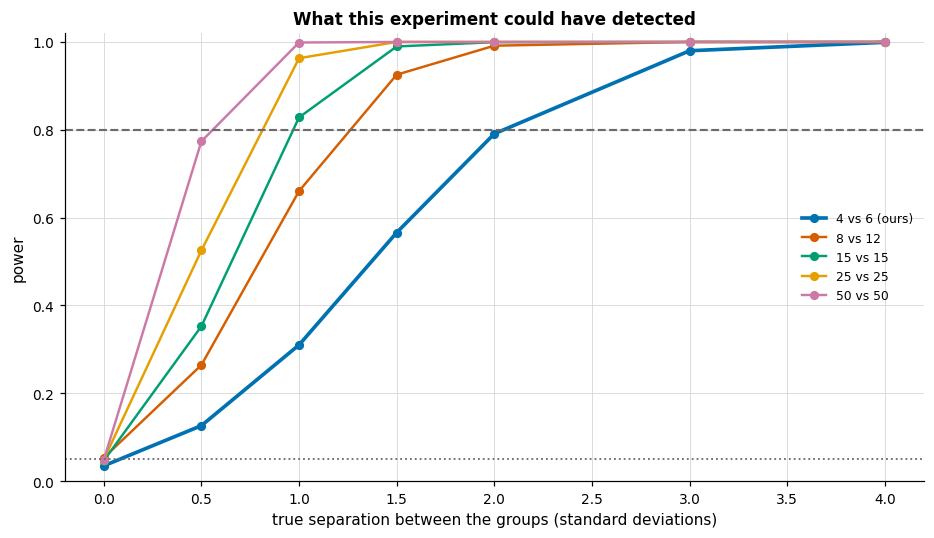

In [4]:
fig, ax = plt.subplots(figsize=(8.6, 5.0))
for (n_s, n_l), colour in zip(GROUP_SIZES, common.CATEGORICAL_COLORS):
    subset = power[(power["n_stable"] == n_s) & (power["n_labile"] == n_l)]
    label = f"{n_s} vs {n_l}" + (" (ours)" if (n_s, n_l) == (n_stable, n_labile) else "")
    ax.plot(subset["effect_size_sd"], subset["power"], marker="o", markersize=5,
            linewidth=2.4 if (n_s, n_l) == (n_stable, n_labile) else 1.6,
            color=colour, label=label)
ax.axhline(0.8, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.axhline(SIGNIFICANCE, color=common.NEUTRAL, linestyle=":", linewidth=1.2)
ax.set_xlabel("true separation between the groups (standard deviations)")
ax.set_ylabel("power")
ax.set_ylim(0, 1.02)
ax.set_title("What this experiment could have detected")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Check 2: does the pipeline recover a signal that is certainly there?

A negative result means nothing if the machinery cannot return a positive one. The
labels are therefore **replaced** by ones the model is guaranteed to predict: each
peptide is relabelled by its own modelled hazard, the top half `labile` and the
bottom half `stable`. The identical discrimination code then has to return a
perfect AUC.

A second, weaker control relabels by a quantity the model does **not** compute —
peptide length — which must come back at whatever length happens to predict.

In [5]:
def separation(values_labile: np.ndarray, values_stable: np.ndarray) -> tuple[float, float]:
    """Return the AUC and one-sided p-value for labile exceeding stable.

    :param values_labile: Metric on the labile group.
    :param values_stable: Metric on the stable group.
    :return: Tuple of AUC and p-value.
    """

    statistic, p_value = mannwhitneyu(values_labile, values_stable, alternative="greater")
    return statistic / (len(values_labile) * len(values_stable)), p_value


reference = discrimination[discrimination["weighting"] == "concentration"].copy()
reference = reference.merge(controls[["short", "sequence"]], on="short", how="left")

planted_rows = []
for name, column, ascending in (
    ("planted: the model's own hazard", "hazard", False),
    ("planted: peptide length", "length", False),
    ("the real annotation", None, None),
):
    frame = reference.copy()
    if column is not None:
        ## The top n_labile peptides by this quantity become the labile group, so the
        ## label is a monotone function of it and a working test must return AUC 1.
        ordered_index = frame.sort_values(column, ascending=ascending).index
        planted = ["labile"] * n_labile + ["stable"] * (len(ordered_index) - n_labile)
        frame["label"] = pd.Series(planted, index=ordered_index)
    else:
        frame["label"] = frame["serum_fate"]
    auc, p_value = separation(
        frame.loc[frame["label"] == "labile", "hazard"].to_numpy(),
        frame.loc[frame["label"] == "stable", "hazard"].to_numpy(),
    )
    planted_rows.append({"labelling": name, "auc": auc, "p_value": p_value})

positive_control = pd.DataFrame(planted_rows)
print(positive_control.round(4).to_string(index=False))
recovered = positive_control.loc[positive_control["labelling"].str.startswith("planted: the model"), "auc"].iloc[0]
if recovered > 0.99:
    print(f"\nthe pipeline recovers a planted signal at AUC {recovered:.3f}: the machinery is sound")
else:
    raise AssertionError(
        f"the discrimination pipeline failed to recover a planted signal (AUC {recovered:.3f}); "
        "every discrimination result in this series is suspect until this is fixed"
    )

                      labelling    auc  p_value
planted: the model's own hazard 1.0000   0.0048
        planted: peptide length 1.0000   0.0048
            the real annotation 0.4167   0.6952

the pipeline recovers a planted signal at AUC 1.000: the machinery is sound


## Check 3: can anything separate these ten peptides?

The model is one predictor. If the labels carry a real physical difference, some
simple property of the sequences should show it — and if nothing does, the labels
are unlikely to be separable by a more elaborate model either.

Eleven elementary predictors are tried. None of them knows anything about
proteases; they are the properties a peptide chemist would look at first.

In [6]:
def features_of(sequence: str) -> dict[str, float]:
    """Return elementary physicochemical descriptors of one peptide.

    :param sequence: Peptide sequence.
    :return: Named descriptors.
    """

    length = len(sequence)
    counts = {residue: sequence.count(residue) for residue in set(sequence)}
    positive = sum(counts.get(r, 0) for r in POSITIVE)
    negative = sum(counts.get(r, 0) for r in NEGATIVE)
    return {
        "length": float(length),
        "net_charge": float(positive - negative),
        "charge_density": (positive - negative) / length,
        "positive_fraction": positive / length,
        "gravy": float(np.mean([HYDROPATHY.get(r, 0.0) for r in sequence])),
        "aromatic_fraction": sum(counts.get(r, 0) for r in AROMATIC) / length,
        "glycine_fraction": counts.get("G", 0) / length,
        "proline_fraction": counts.get("P", 0) / length,
        "lysine_fraction": counts.get("K", 0) / length,
        "arginine_fraction": counts.get("R", 0) / length,
        "distinct_residues": float(len(counts)),
    }


feature_frame = pd.DataFrame([features_of(s) for s in controls["sequence"]])
feature_frame["serum_fate"] = controls["serum_fate"].to_numpy()
feature_frame["short"] = controls["short"].to_numpy()
feature_frame["source"] = controls["source"].to_numpy()

predictor_rows = []
for column in feature_frame.columns:
    if column in ("serum_fate", "short", "source"):
        continue
    labile_values = feature_frame.loc[feature_frame["serum_fate"] == "labile", column].to_numpy()
    stable_values = feature_frame.loc[feature_frame["serum_fate"] == "stable", column].to_numpy()
    ## Two-sided in spirit: a predictor separating in either direction is a finding
    auc_up, p_up = separation(labile_values, stable_values)
    predictor_rows.append(
        {
            "predictor": column,
            "auc": auc_up,
            "p_one_sided": p_up,
            "distance_from_chance": abs(auc_up - 0.5),
        }
    )
## And the model itself, for comparison on the same axis
for metric in ("hazard", "hazard_per_bond"):
    auc_up, p_up = separation(
        reference.loc[reference["serum_fate"] == "labile", metric].to_numpy(),
        reference.loc[reference["serum_fate"] == "stable", metric].to_numpy(),
    )
    predictor_rows.append(
        {"predictor": f"model: {metric}", "auc": auc_up, "p_one_sided": p_up,
         "distance_from_chance": abs(auc_up - 0.5)}
    )

predictors = pd.DataFrame(predictor_rows).sort_values("distance_from_chance", ascending=False)
print(predictors.round(4).to_string(index=False))

## How extreme is the best of thirteen, given that thirteen were tried?
best = predictors["distance_from_chance"].max()
null_best = []
for _ in range(2000):
    shuffled = rng.permutation(feature_frame["serum_fate"].to_numpy())
    distances = []
    for column in feature_frame.columns:
        if column in ("serum_fate", "short", "source"):
            continue
        values = feature_frame[column].to_numpy()
        auc, _ = separation(values[shuffled == "labile"], values[shuffled == "stable"])
        distances.append(abs(auc - 0.5))
    null_best.append(max(distances))
family_p = (1 + int(np.sum(np.array(null_best) >= best))) / (1 + len(null_best))
print(f"\nbest predictor is {best:.3f} from chance")
print(f"probability that the best of this many predictors reaches that by chance: {family_p:.4f}")

             predictor    auc  p_one_sided  distance_from_chance
     aromatic_fraction 0.8750       0.0341                0.3750
     arginine_fraction 0.7292       0.1261                0.2292
        charge_density 0.6875       0.1962                0.1875
            net_charge 0.6667       0.2264                0.1667
     positive_fraction 0.6667       0.2264                0.1667
                 gravy 0.3750       0.7619                0.1250
      glycine_fraction 0.3750       0.7997                0.1250
         model: hazard 0.4167       0.6952                0.0833
       lysine_fraction 0.5417       0.4573                0.0417
model: hazard_per_bond 0.5417       0.4571                0.0417
                length 0.5208       0.5000                0.0208
     distinct_residues 0.5208       0.5000                0.0208
      proline_fraction 0.4792       0.6195                0.0208



best predictor is 0.375 from chance
probability that the best of this many predictors reaches that by chance: 0.2229


### Reading the figure

Every predictor on one axis, distance from chance. The shaded band is where the
best of thirteen predictors would fall 95% of the time if the labels were random,
computed by permuting the labels and re-running all thirteen. A bar inside that
band is indistinguishable from the best of thirteen coin flips, however good it
looks on its own.

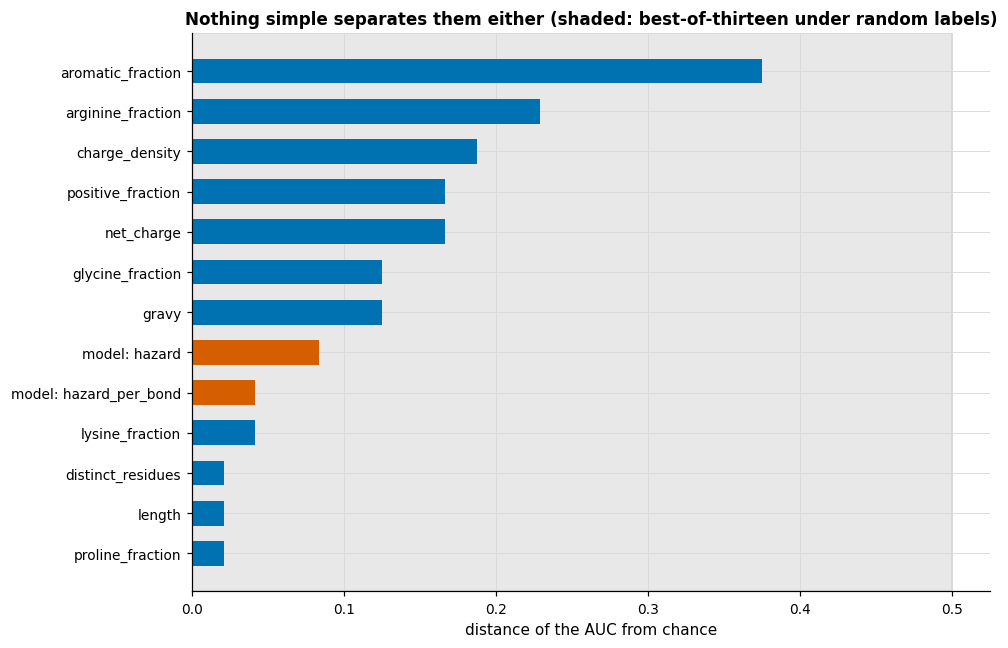

In [7]:
fig, ax = plt.subplots(figsize=(9.2, 6.0))
ordered = predictors.sort_values("distance_from_chance")
colours = [
    common.CATEGORICAL_COLORS[1] if name.startswith("model") else common.CATEGORICAL_COLORS[0]
    for name in ordered["predictor"]
]
ax.barh(ordered["predictor"], ordered["distance_from_chance"], color=colours, height=0.62)
ax.axvspan(0, float(np.percentile(null_best, 95)), color=common.NEUTRAL, alpha=0.15, zorder=0)
ax.set_xlabel("distance of the AUC from chance")
ax.set_title("Nothing simple separates them either (shaded: best-of-thirteen under random labels)")
fig.tight_layout()
plt.show()

In [8]:
common.save_result(power, "3_04_power.csv")
common.save_result(positive_control, "3_04_positive_control.csv")
common.save_result(predictors, "3_04_alternative_predictors.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/3_04_alternative_predictors.csv')

## Findings and decisions

The three checks attribute the negative result of `3_03`, and the second of them
caught a defect in this notebook's own code before it could be reported as a
conclusion.

### Check 1: the experiment was not powerless, but nearly

| true separation (SD) | power at 4 vs 6 | at 8 vs 12 | at 25 vs 25 |
| --- | --- | --- | --- |
| 0.5 | 0.13 | 0.26 | 0.53 |
| 1.0 | 0.31 | 0.66 | 0.96 |
| 1.5 | 0.57 | 0.93 | 1.00 |
| **2.0** | **0.79** | 0.99 | 1.00 |
| 3.0 | 0.98 | 1.00 | 1.00 |

A perfect separation returns $p = 0.0048$, so the test can reach significance. But
reliably detecting anything smaller than a **two-standard-deviation** separation was
never possible: at a one-SD effect — already large by any convention — the power is
**31%**, so a real effect of that size would have come back negative two times in
three. Doubling the panel to 8 against 12 would take that to 66%, and 25 against 25
to 96%.

**The negative therefore bounds the effect rather than excluding it.** What `3_03`
established is that there is no effect of two standard deviations or more. An effect
of one SD is entirely compatible with what was seen.

### Check 2: the machinery is sound, and it found a bug in itself

Relabelling the peptides by the model's own hazard returns **AUC 1.000,
$p = 0.0048$**, as it must when the label is a monotone function of the quantity
tested. The discrimination code, the metric and the test are all correct.

The first run of this check returned **0.750**, which is impossible for a planted
signal. The cause was a defect in the relabelling here — three conflicting
assignments scrambling labels against their index — and not in the pipeline under
test. The check is now a hard assertion rather than a warning, so a future failure
cannot be read past.

### The second control turned into a finding

Relabelling by **peptide length** also returns AUC 1.000 — meaning the modelled
hazard separates a purely length-based split of these peptides perfectly. That is
not a control result, it is a statement about the model:

| weighting | Spearman(length, hazard) |
| --- | --- |
| `concentration_only` | **+1.000** |
| `uniform` | +0.909 |
| `concentration` | +0.756 |
| `elastase_only` | +0.232 |

On these ten peptides the hazard **is** a length ranking, almost exactly. With the
score switched off it is one by construction, since hazard is then proportional to
the bond count; with the score on it barely departs from it. This is the same defect
`3_01` reports from the other direction — the model's length dependence is $+0.45$
while the measurements run the other way at $-0.274$ — and it explains why no
weighting separates the labels: the labels are confounded with length in opposite
directions between the two sources (`3_03`), and the model is close to a pure length
predictor, so the two source-halves cancel.

### Check 3: nothing simple separates them either

Thirteen predictors were tried. The best is `aromatic_fraction` at AUC 0.875, which
taken alone has $p = 0.034$ — but the permutation null over all thirteen puts the
probability of the best-of-thirteen reaching that far from chance at **0.22**. It is
what the best of thirteen coin flips looks like.

Every other predictor, including the model's two metrics, sits inside the band.

### What this means for the project

**The negative in `3_03` is attributable to the data and to the sample size, not to
a defect.** The pipeline recovers a planted signal perfectly; ten peptides cannot see
an effect below two standard deviations; and no simple property of these sequences
separates the labels either.

Three consequences, in order of how actionable they are.

1. **The model is close to a length predictor on short peptides, and that is the
   real problem.** It is not that the hazard carries no information — `3_02` shows
   it ranks bonds within a peptide correctly — but that between peptides it is
   dominated by how many bonds there are. Any between-peptide claim inherits this.
2. **This annotation should be retired as a validation target.** It cannot decide
   the question either way, and continuing to test against it produces negatives
   that mean nothing.
3. **More labelled peptides would help, and the amount needed is now known.**
   Twenty-five against twenty-five would detect a one-SD effect 96% of the time,
   against 31% today.